In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
tips=sns.load_dataset('tips')
titanic=sns.load_dataset('titanic')

# Task 1.1: The Distribution: Visualize the distribution of the total bill amounts. Ensure the plot shows both the frequency bins and a smoothed density curve.

In [10]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


Text(0, 0.5, 'Frequency')

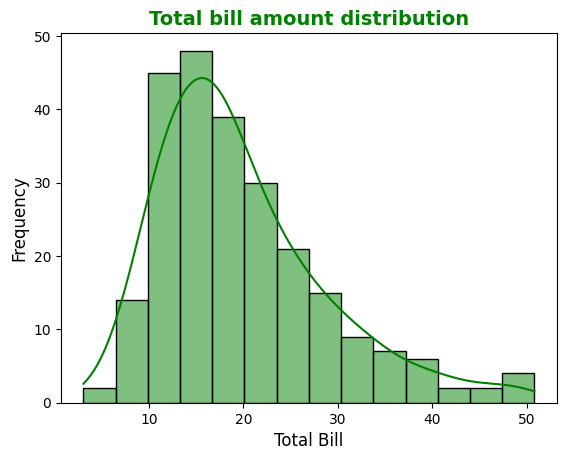

In [11]:
sns.histplot(x='total_bill',data=tips, kde=True, bins=14, color='green')
plt.title('Total bill amount distribution',fontsize=14,fontweight='bold',color='green')
plt.xlabel('Total Bill',fontsize=12)
plt.ylabel('Frequency',fontsize=12)        

# Task 1.2: The Categorical Count: Create a plot that displays the total number of tables served on each day of the week present in the dataset. Order the days chronologically.

/var/folders/lw/f5qy2qvj20qfwyw16w6_dp7m0000gn/T/ipykernel_68101/934882231.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=tips['day'], order=ascending_order, palette='Blues')


Text(0, 0.5, 'Tables Served')

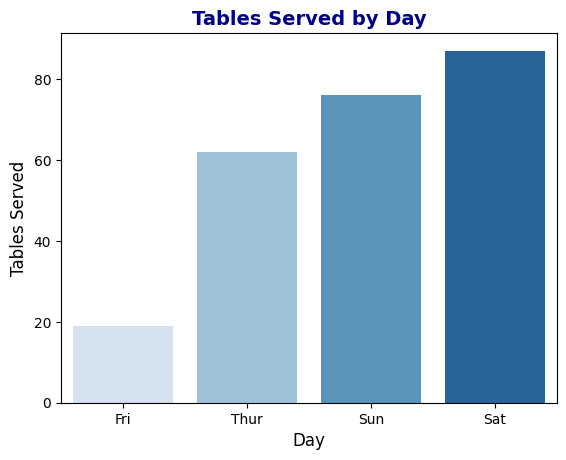

In [12]:
ascending_order=tips['day'].value_counts().sort_values(ascending=True).index
sns.countplot(x=tips['day'], order=ascending_order, palette='Blues')
plt.title('Tables Served by Day',fontsize=14, fontweight='bold',color='darkblue')
plt.xlabel('Day',fontsize=12)
plt.ylabel('Tables Served',fontsize=12)

# Task 1.3: The Category vs. Numeric: Compare the distribution of tip amounts across the different days of the week. Display the median, quartiles, and any outliers for each day.

Text(0.5, 1.0, 'Tip amount by day')

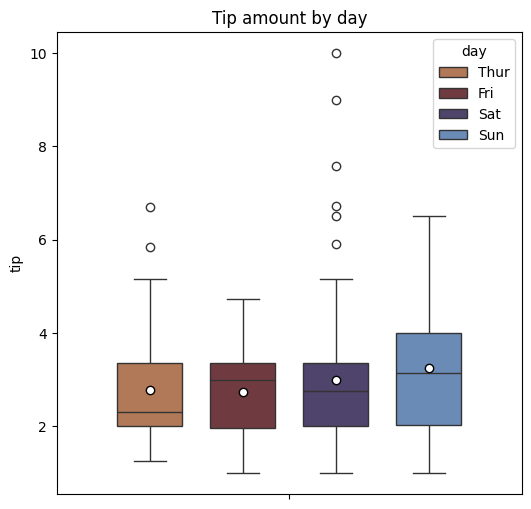

In [13]:
plt.figure(figsize=(6,6))
sns.boxplot(y='tip', data=tips, hue='day', palette='managua',gap=0.3, showmeans=True, meanprops={'marker':'o',
                                                                                                'markerfacecolor':'white',
                                                                                                'markeredgecolor':'black'})
plt.title('Tip amount by day')

# Task 1.4: The Bivariate Relationship: Plot the relationship between the total bill and the tip amount.

Text(0, 0.5, 'Tip')

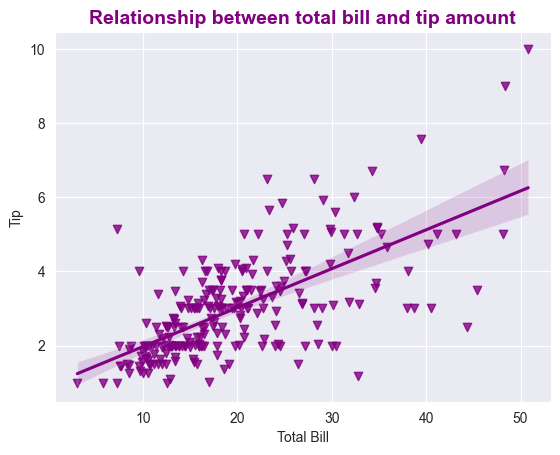

In [14]:
sns.set_style('darkgrid')
sns.regplot(x='total_bill',y='tip',data=tips,color='purple',marker='v',scatter=True)
plt.title('Relationship between total bill and tip amount', fontsize=14, fontweight='bold',color='purple')
plt.xlabel('Total Bill')
plt.ylabel('Tip')

# Task 1.5: Adding Dimensions: Take the plot from Task 1.4 and modify it so that the points are colored based on whether it was lunch or dinner, and the shape of the points changes based on the gender of the bill payer.

Text(0, 0.5, 'Tip')

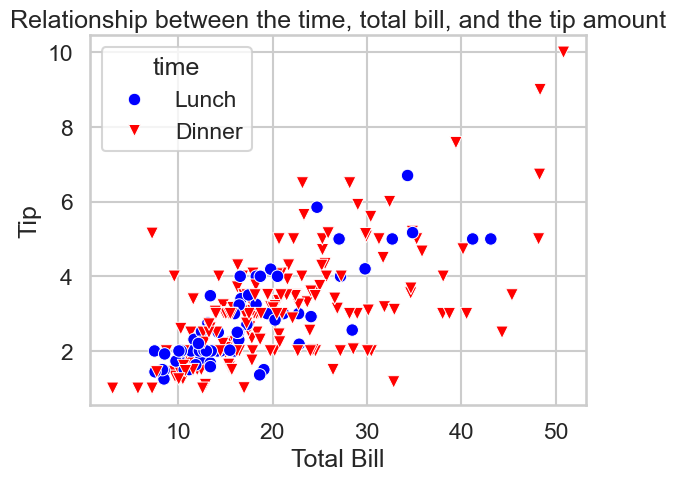

In [15]:
sns.set_style('whitegrid')
sns.set_context('talk')
sns.scatterplot(x='total_bill',y='tip',data=tips, hue='time',style='time',markers=['o','v'],palette=['blue','red'])

plt.title('Relationship between the time, total bill, and the tip amount')
plt.xlabel('Total Bill')
plt.ylabel('Tip')

# Task 1.6: The Grid: Create a grid of subplots that shows the relationship between the total bill and the tip amount, but separate the data into individual plots for each combination of time (Lunch/Dinner) and smoker (Yes/No).

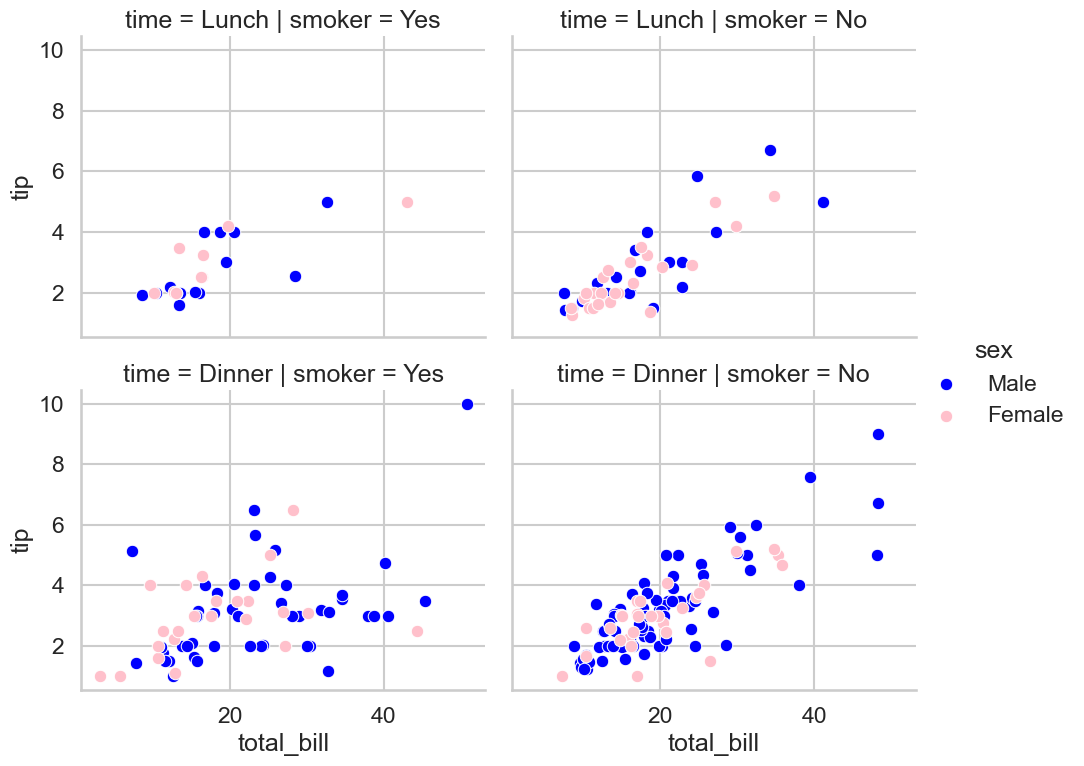

In [34]:

g=sns.FacetGrid(tips,row='time',col='smoker', height=4, aspect=1.2, hue='sex',palette=['blue','pink'])
g.map(sns.scatterplot,'total_bill','tip')
g.tight_layout()
g.add_legend()

# Task 2.1: The Missing Data: Visualize the missing values in the titanic dataset so you can quickly see which columns have the most nulls at a glance. (No data cleaning required, just visualize the null state).

In [35]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


<Axes: >

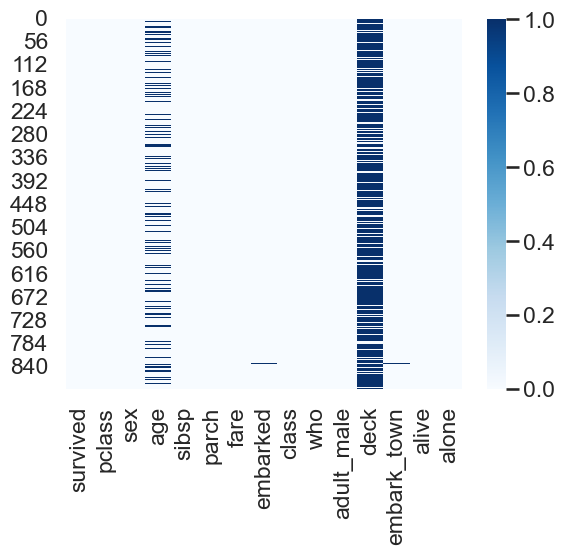

In [63]:
missing_values=titanic.isnull()
sns.heatmap(missing_values,cmap='Blues')

# Task 2.2: The Composition: Show the survival count (how many lived vs. died), but break each group down by the passenger class (pclass).

/var/folders/lw/f5qy2qvj20qfwyw16w6_dp7m0000gn/T/ipykernel_68101/2706273663.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Survived','Survived'])


Text(0.5, 1.0, 'Relationship between passenger class and survival rate')

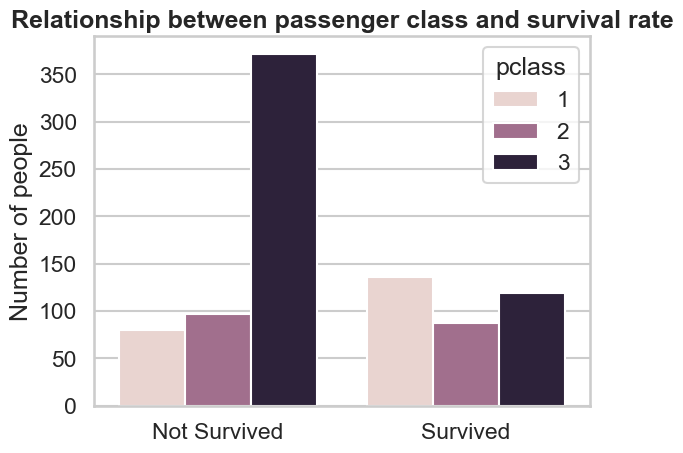

In [75]:
fig,ax=plt.subplots()

sns.countplot(x='survived',data=titanic, hue='pclass')
ax.set_xticklabels(['Not Survived','Survived'])
ax.set_xlabel('')
ax.set_ylabel('Number of people')
ax.set_title('Relationship between passenger class and survival rate', fontweight='bold',fontsize=18)

# Task 2.3: Overlapping Distributions: Compare the age distribution of passengers who survived against those who did not. Both distributions should be on the same axes, with some transparency so you can see where they overlap.

Text(0.5, 0, 'Age')

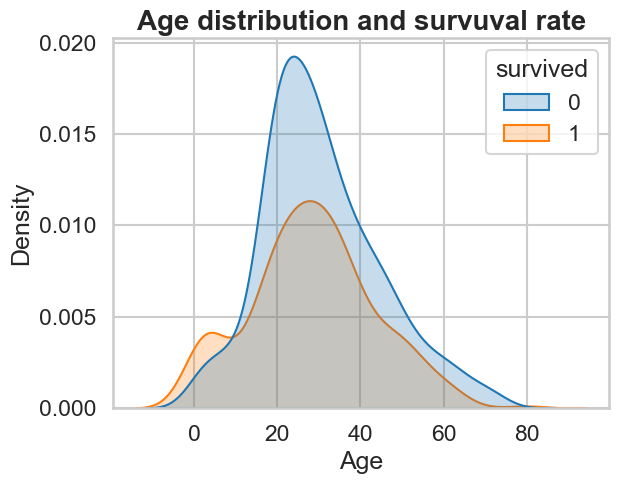

In [87]:
sns.kdeplot(x='age',data=titanic, hue='survived', fill=True)
plt.title('Age distribution and survuval rate', fontsize=20, fontweight='bold')
plt.xlabel('Age')

# Task 2.4: The Detailed Category: Visualize the distribution of fares paid across the three passenger classes. Split each class's distribution in half to directly compare the fares of those who survived versus those who didn't, all within the same plot structure.

<Axes: xlabel='pclass', ylabel='fare'>

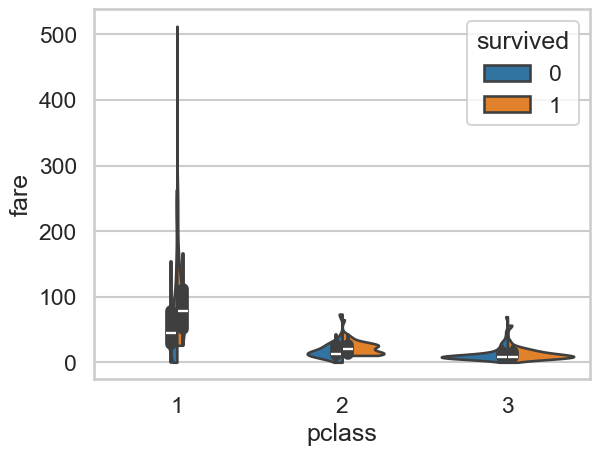

In [99]:

sns.violinplot(x='pclass',y='fare', data=titanic,hue='survived',split=True,cut=0)

# Task 2.5: The Correlation Matrix: Calculate the correlation between all numerical columns in the titanic dataset and visualize this correlation matrix. Include the actual correlation values as text inside the plot and use a diverging color map (e.g., blue to red).

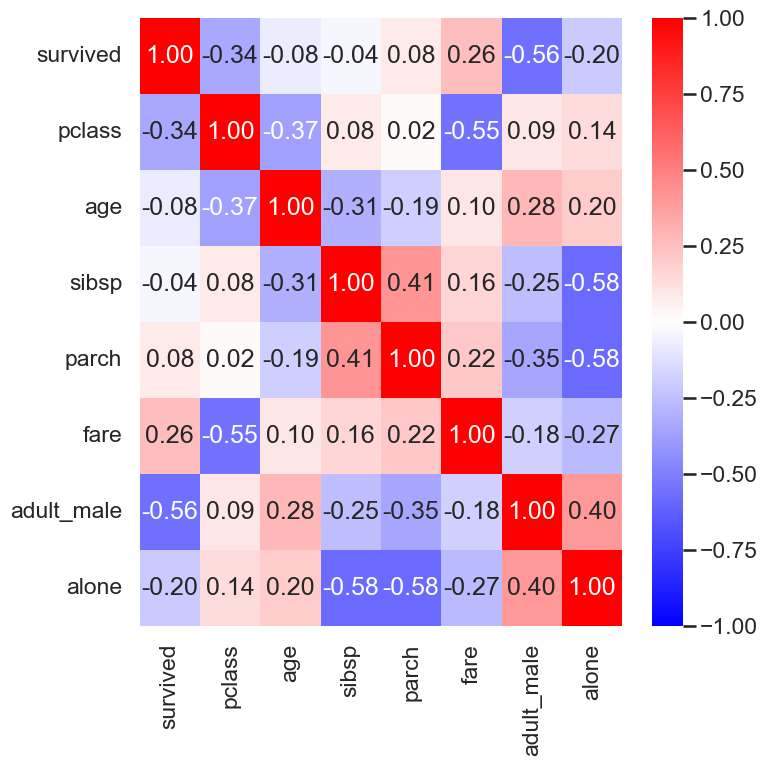

In [108]:
plt.figure(figsize=(8,8))
correlation=titanic.corr(numeric_only=True)
sns.heatmap(correlation, cmap='bwr', annot=True, vmin=-1, vmax=1, fmt='.2f')
plt.tight_layout()

# Task 3.1: The Custom Subplot Figure: Create a single figure with a 2x2 grid of subplots using the titanic dataset.

Top-Left: A count of passengers by gender.

Top-Right: The survival rate (percentage, not raw count) by gender.

Bottom-Left: The distribution of passenger ages.

Bottom-Right: A scatter plot of age vs. fare.

Text(0, 0.5, 'Fare')

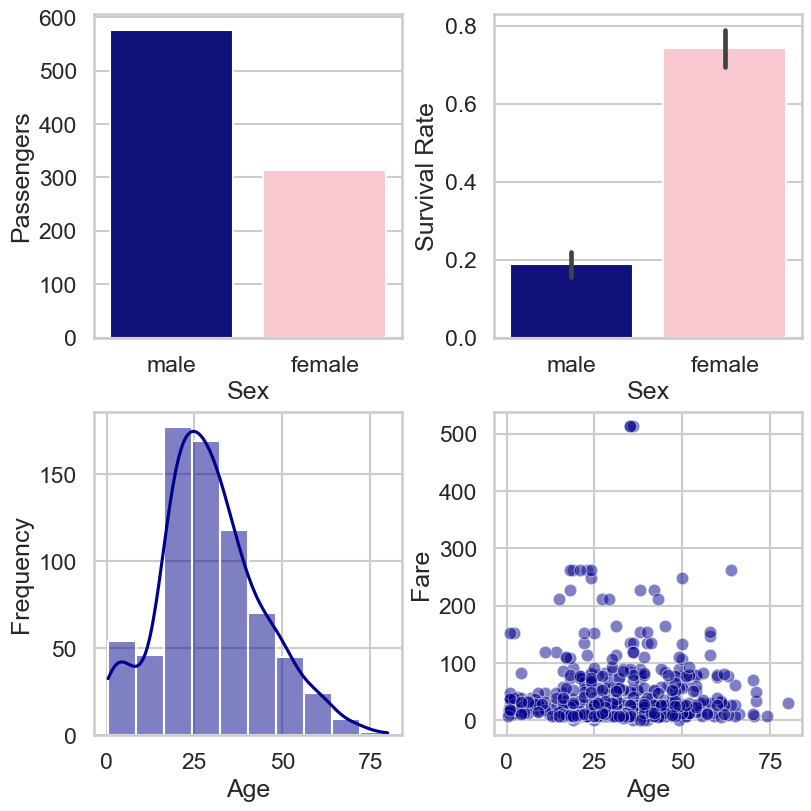

In [165]:
fig, axs = plt.subplots(nrows=2, ncols=2,figsize=(8,8),layout='constrained')
sns.countplot(x='sex',data=titanic,ax=axs[0,0],hue='sex',legend=False, palette=['darkblue','pink'])
axs[0,0].set_xlabel('Sex')
axs[0,0].set_ylabel('Passengers')

sns.barplot(x='sex',y='survived',data=titanic, hue='sex',ax=axs[0,1],legend=False, palette=['darkblue','pink'])
axs[0,1].set_xlabel('Sex')
axs[0,1].set_ylabel('Survival Rate')

sns.histplot(titanic['age'],kde=True, ax=axs[1,0],bins=10, color='darkblue')
axs[1,0].set_xlabel('Age')
axs[1,0].set_ylabel('Frequency')

sns.scatterplot(x='age',y='fare',data=titanic,ax=axs[1,1],color='darkblue',alpha=0.5)
axs[1,1].set_xlabel('Age')
axs[1,1].set_ylabel('Fare')

# Task 3.2: Publication-Ready Polish: Take the bottom-right plot (age vs. fare) from your grid and recreate it as a standalone, highly customized plot.

Change the background style to a dark grid.

Add a clear, descriptive main title and formatted axis labels.

Adjust the axis limits so the plot focuses on fares under $300.

Add a text annotation pointing to a specific interesting outlier (e.g., an older passenger who paid a high fare).

Save the final plot to your local directory as a .png file with a high resolution (300 dpi).

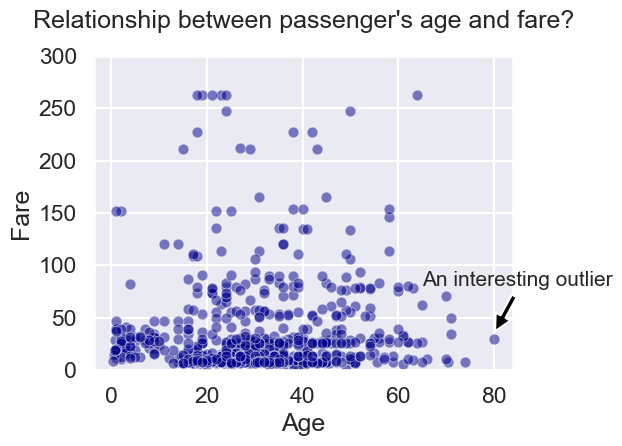

In [191]:

sns.set_style('darkgrid')

plt.title('Relationship between passenger\'s age and fare?',pad=20)
sns.scatterplot(x='age',y='fare',data=titanic,color='darkblue',alpha=0.5,s=60)

plt.xlabel('Age')
plt.ylabel('Fare')

plt.annotate('An interesting outlier',xy=(80,35), xytext=(65, 80), fontsize=15, arrowprops={'facecolor':'black', 'shrink':0.05})

plt.ylim(0,300)
plt.tight_layout()

plt.savefig('titanic_fare_outlier.png',dpi=300, bbox_inches='tight' )